In [5]:
pip install kagglehub

In [26]:

import kagglehub

In [7]:


# Download latest version
path = kagglehub.dataset_download("techsash/waste-classification-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Path to dataset files: /kaggle/input/waste-classification-data


In [20]:
import shutil
import os

source_directory = "/kaggle/input/waste-classification-data"
destination_directory = "waste_classification_data"  # Visible directory name (relative path)

# Create the destination directory if it doesn't exist
if not os.path.exists(destination_directory):
    os.makedirs(destination_directory)

# Construct the full destination path
full_destination_path = os.path.join(destination_directory, "1") #Creates a folder called 1 inside the destination folder.

try:
    shutil.copytree(source_directory, full_destination_path)
    print(f"Directory copied to: {full_destination_path}")
except FileExistsError:
    print(f"Destination directory '{full_destination_path}' already exists.")
except FileNotFoundError:
    print(f"Source directory '{source_directory}' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Destination directory 'waste_classification_data/1' already exists.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm
import cv2


Attempting to load data from: waste_classification_data/1/DATASET/TRAIN


Loading O: 100%|██████████| 12565/12565 [00:11<00:00, 1137.65it/s]


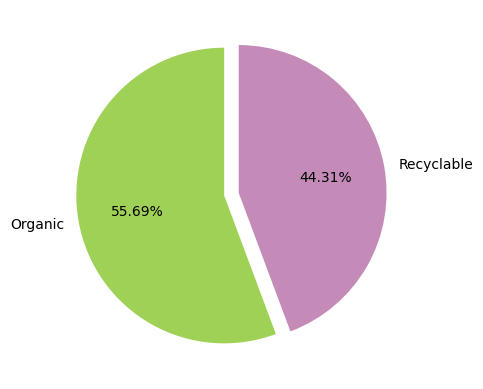

In [43]:
# x_data = []
# y_data = []

# for category in glob(train_path+'/*'):
#     for file in tqdm(glob(category+'/*')):
#         img_array=cv2.imread(file)
#         img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
#         x_data.append(img_array)
#         y_data.append(category.split("/")[-1])

# data=pd.DataFrame({'image': x_data,'label': y_data})
full_destination_path = 'waste_classification_data/1'

train_path = os.path.join(full_destination_path, 'DATASET', 'TRAIN')

print(f"Attempting to load data from: {train_path}")

if not os.path.exists(train_path):
    print(f"Error: The training path '{train_path}' does not exist. Please check the dataset structure.")
    data = pd.DataFrame({'image': [], 'label': []})
else:
    categories_found = glob(train_path + '/*')
    if not categories_found:
        print(f"Warning: No categories found in '{train_path}'. Data will be empty.")
        data = pd.DataFrame({'image': [], 'label': []})
    else:
        for category in categories_found:
            files_found = glob(category + '/*')
            if not files_found:
                print(f"Warning: No files found in category '{category}'.")
                continue

            for file in tqdm(files_found, desc=f"Loading {os.path.basename(category)}"):
                img_array = cv2.imread(file)
                if img_array is not None:
                    img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
                    x_data.append(img_array)
                    y_data.append(category.split("/")[-1])
                else:
                    print(f"Warning: Could not read image file {file}")

    data = pd.DataFrame({'image': x_data, 'label': y_data})

colors = ['#a0d157','#c48bb8']

if not data.empty and not data.label.empty:
    plt.pie(data.label.value_counts(), startangle=90, explode=[0.05, 0.05], autopct='%0.2f%%',
            labels=['Organic', 'Recyclable'], colors=colors, radius=1)
    plt.show()
else:
    print("Cannot plot pie chart: Data is empty after loading or contains no labels.")

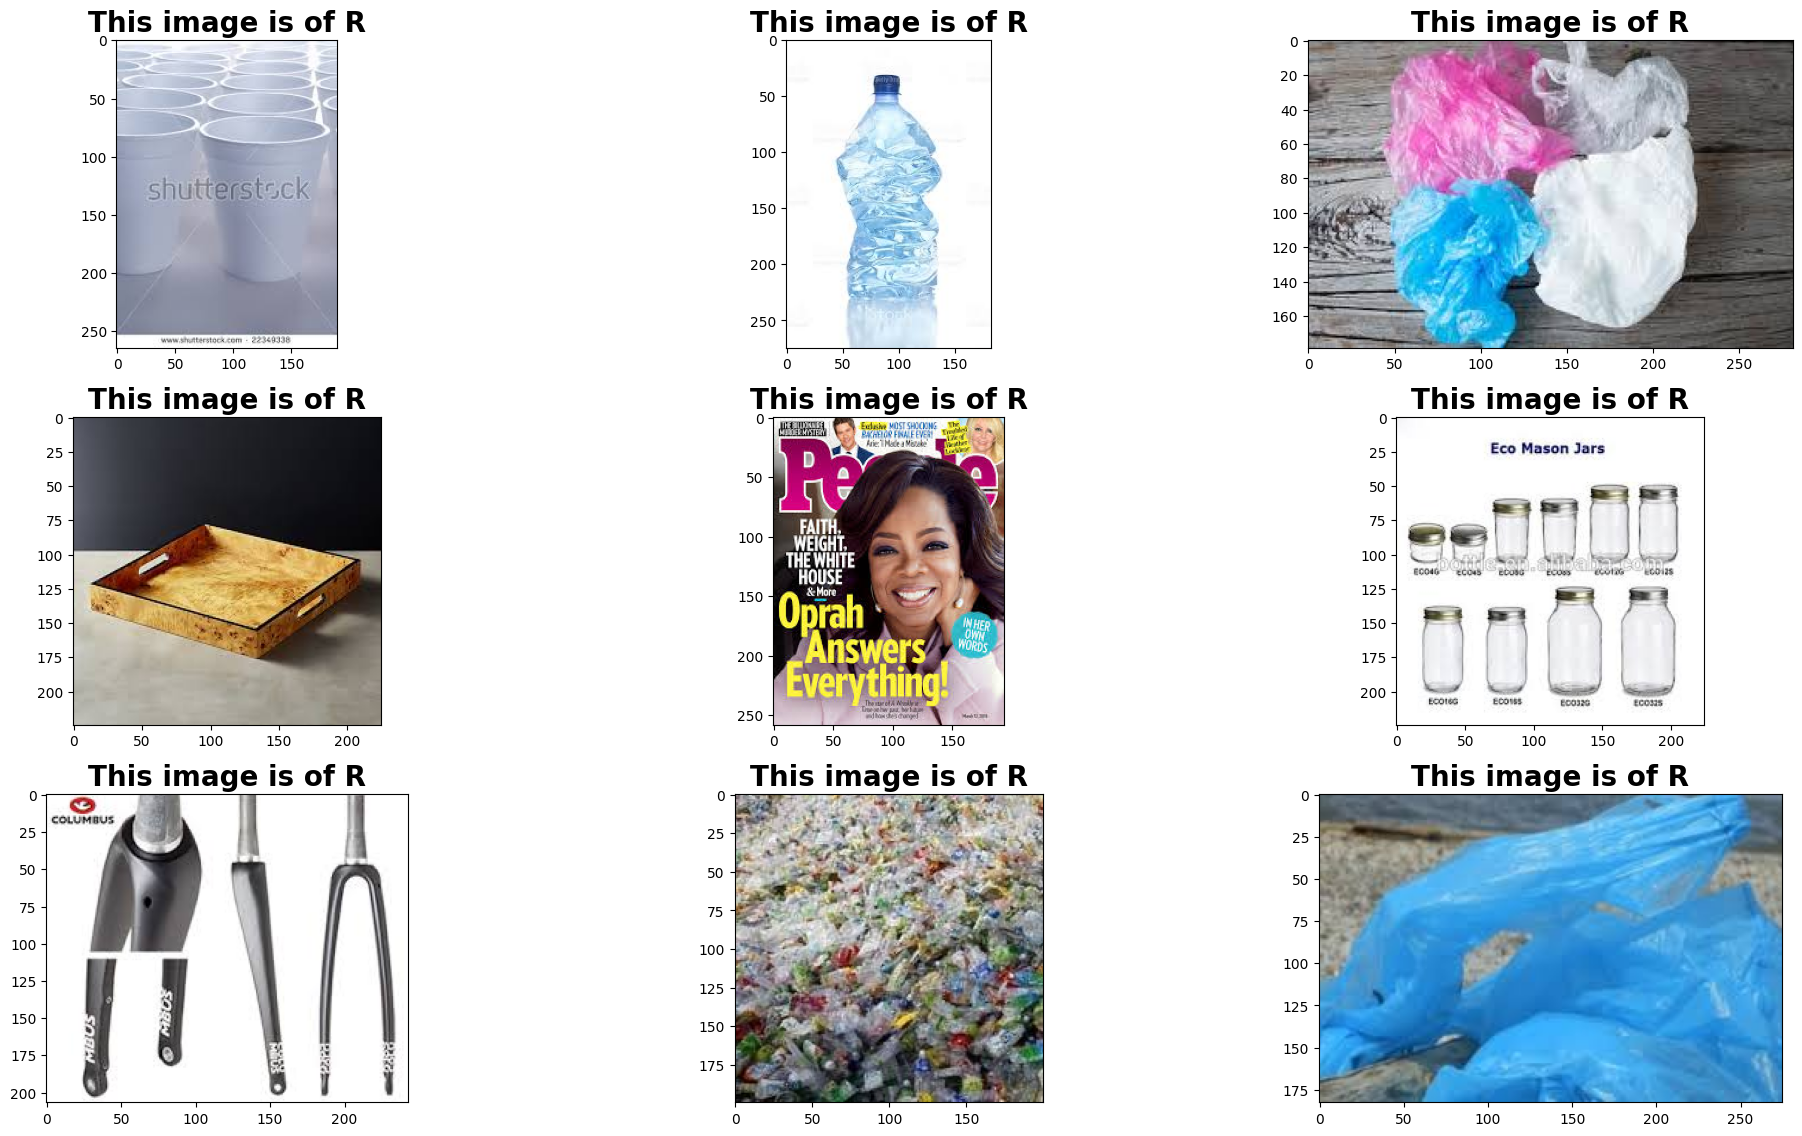

In [44]:
plt.figure(figsize=(20,15))
for i in range(9):
    plt.subplot(4,3,(i%12)+1)
    index=np.random.randint(15000)
    plt.title('This image is of {0}'.format(data.label[index]),fontdict={'size':20,'weight':'bold'})
    plt.imshow(data.image[index])
    plt.tight_layout()